In [82]:
library(tidyverse)
library(ellipse) 
library(mvnTest) 

In [83]:
X <- matrix(c(2, 8, 6, 8, 12, 9, 9, 10), 
            ncol = 2, byrow = FALSE)

mu_0 <- c(7, 11)

n <- nrow(X)
p <- ncol(X)
x_bar <- colMeans(X)
S <- cov(X)

# a 
T2 <- n * t(x_bar - mu_0) %*% solve(S) %*% (x_bar - mu_0)
T2 <- as.numeric(T2)
cat("T-squared value:", T2, "\n")

# (b
F_stat <- ((n - p) / (p * (n - 1))) * T2
cat("\nDistribution: F-statistic =", round(F_stat, 4), 
    "with df1 =", p, "and df2 =", n-p, "\n")

# c
alpha <- 0.05
F_crit <- qf(1 - alpha, df1 = p, df2 = n - p)
T2_crit <- ((n - 1) * p / (n - p)) * F_crit

cat("\nCritical T-squared value:", T2_crit, "\n")
p_value <- 1 - pf((n - p) / ((n - 1) * p) * T2, df1 = p, df2 = n - p)
cat("P-value:", p_value, "\n")

if(T2 > T2_crit) {
  print("Reject the null hypothesis H0.\n")
} else {
  print("Fail to reject the null hypothesis H0.\n")
}

T-squared value: 13.63636 

Distribution: F-statistic = 4.5455 with df1 = 2 and df2 = 2 

Critical T-squared value: 57 
P-value: 0.1803279 
[1] "Fail to reject the null hypothesis H0.\n"


c. The critical $T^{2}$ value at the $\alpha = 0.05$ significance level is 57. Because the calculated $T^{2}$ statistic (13.63636) is less than the critical value (57), the resulting p-value is 0.1803279. Since the p-value is greater than 0.05, the statistical conclusion is that we fail to reject the null hypothesis $H_{0}$.

95% Simultaneous Confidence Intervals
            Lower_SCI Upper_SCI
Weight       69.55347 121.48653
Body_Length 152.17278 176.58722
Neck_Girth   49.60667  61.77333
Girth        83.48823 103.29177
Head_Length  16.54687  19.41313
Head_Width   29.03513  33.22487

95% Bonferroni Confidence Intervals 
            Lower_Bonf Upper_Bonf
Weight        75.55331  115.48669
Body_Length  154.99339  173.76661
Neck_Girth    51.01229   60.36771
Girth         85.77614  101.00386
Head_Length   16.87801   19.08199
Head_Width    29.51917   32.74083

95% Bonferroni Confidence Interval for (Head Width - Head Length)
Estimate: 13.15 | CI: [12.49, 13.81]


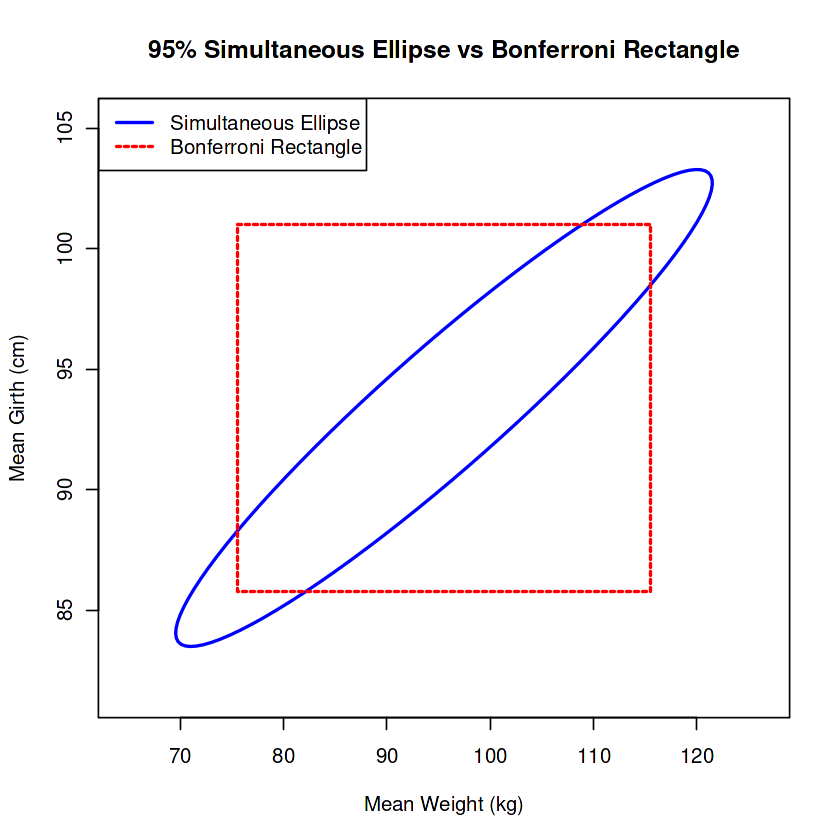

In [84]:
n <- 61
p <- 6
alpha <- 0.05
x_bar <- c(95.52, 164.38, 55.69, 93.39, 17.98, 31.13)
names(x_bar) <- c("Weight", "Body_Length", "Neck_Girth", "Girth", "Head_Length", "Head_Width")

S <- matrix(c(
  3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37,
  1343.97, 721.91,  324.25, 537.35,  80.17,  117.73,
  731.54,  324.25,  179.28, 281.17,  39.15,  56.80,
  1175.50, 537.35,  281.17, 474.98,  63.73,  94.85,
  162.68,  80.17,   39.15,  63.73,   9.95,   13.88,
  238.37,  117.73,  56.80,  94.85,   13.88,  21.26
), nrow = 6, byrow = TRUE)

se <- sqrt(diag(S) / n)

# a
chi2_val <- qchisq(1 - alpha, p)
sci_lower <- x_bar - sqrt(chi2_val) * se
sci_upper <- x_bar + sqrt(chi2_val) * se
sci_df <- data.frame( Lower_SCI = sci_lower, Upper_SCI = sci_upper)
cat("95% Simultaneous Confidence Intervals\n")
print(sci_df)

# c
m <- 6
t_val_bonf <- qt(1 - alpha / (2 * m), n - 1)
bonf_lower <- x_bar - t_val_bonf * se
bonf_upper <- x_bar + t_val_bonf * se
bonf_df <- data.frame(Lower_Bonf = bonf_lower, Upper_Bonf = bonf_upper)
cat("\n95% Bonferroni Confidence Intervals \n")
print(bonf_df)

sub_x_bar <- x_bar[c(1, 4)]
sub_S <- S[c(1, 4), c(1, 4)]

radius_simult <- sqrt(qchisq(1 - alpha, p) / n)
ell_points <- ellipse::ellipse(x = sub_S, centre = as.numeric(sub_x_bar), t = radius_simult)

plot(ell_points, type = "l", col = "blue", lwd = 2,
     xlab = "Mean Weight (kg)", ylab = "Mean Girth (cm)",
     main = "95% Simultaneous Ellipse vs Bonferroni Rectangle",
     xlim = c(sci_df$Lower_SCI[1] - 5, sci_df$Upper_SCI[1] + 5),
     ylim = c(sci_df$Lower_SCI[4] - 2, sci_df$Upper_SCI[4] + 2))

rect(bonf_df$Lower_Bonf[1], bonf_df$Lower_Bonf[4],
     bonf_df$Upper_Bonf[1], bonf_df$Upper_Bonf[4],
     border = "red", lwd = 2, lty = 2)
legend("topleft", legend = c("Simultaneous Ellipse", "Bonferroni Rectangle"),
       col = c("blue", "red"), lty = c(1, 2), lwd = 2)

# e
m_new <- 7
t_val_bonf_new <- qt(1 - alpha / (2 * m_new), n - 1)
diff_mean <- x_bar[6] - x_bar[5]

diff_se <- sqrt((S[6,6] + S[5,5] - 2 * S[5,6]) / n)
lower_diff <- diff_mean - t_val_bonf_new * diff_se
upper_diff <- diff_mean + t_val_bonf_new * diff_se
cat("\n95% Bonferroni Confidence Interval for (Head Width - Head Length)\n")
cat(sprintf("Estimate: %.2f | CI: [%.2f, %.2f]\n", diff_mean, lower_diff, upper_diff))

The Simultaneous Ellipse (solid blue line) is wider and tilted because weight and girth have a positive relationship. Meanwhile, the Bonferroni Rectangle (dashed red line) is aligned with the axes and gives individual intervals. Overall, the ellipse is larger because it considers the relationship between the two variables, while the rectangle mostly stays within the ellipse but extends slightly at the corners.

90% Simultaneous Confidence Intervals
   Variable     Lower    Upper
Cr       Cr -6.881173 17.25228
St       St -4.826957 36.96696

T^2 statistic for [0.30, 10]: 1.772481 
Critical Value: 7.445582 


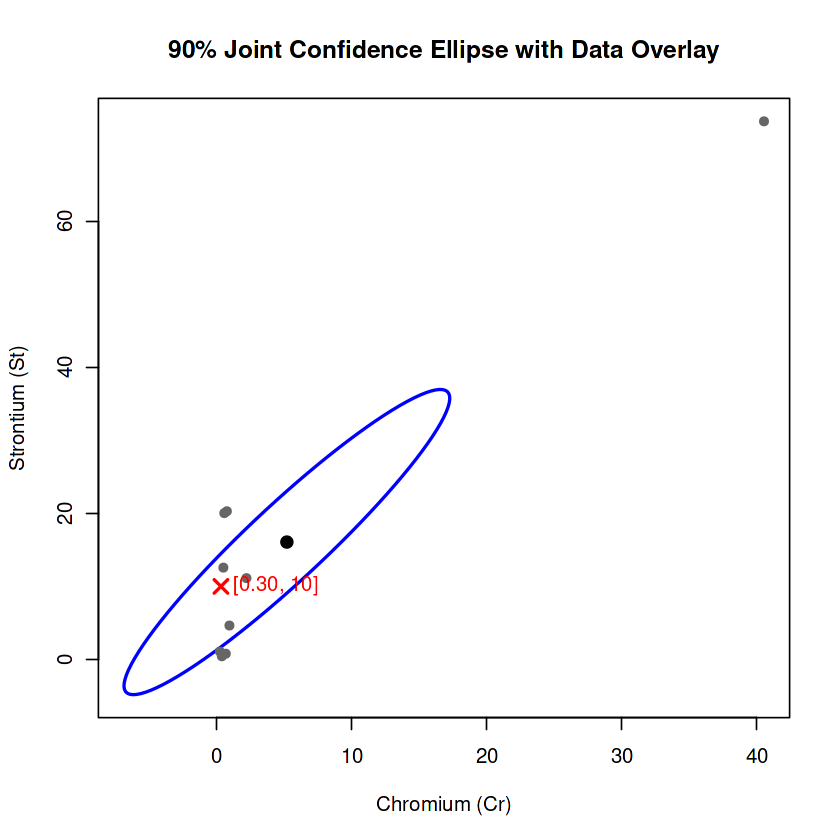


After Outlier Removal
T^2 statistic for [0.30, 10]: 5.307872 
Critical Value: 8.081043 


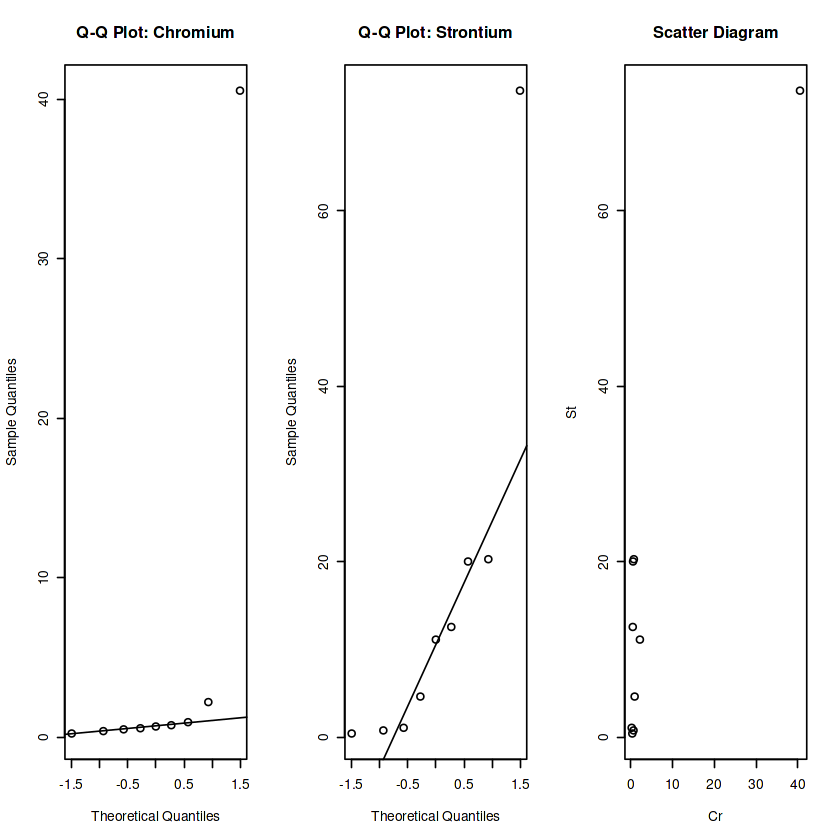

In [110]:
Cr <- c(0.48, 40.53, 2.19, 0.55, 0.74, 0.66, 0.93, 0.37, 0.22)
St <- c(12.57, 73.68, 11.13, 20.03, 20.29, 0.78, 4.64, 0.43, 1.08)
data_hairs <- data.frame(Cr, St)
n <- nrow(data_hairs)
p <- 2
alpha <- 0.10

x_bar <- colMeans(data_hairs)
S <- cov(data_hairs)

# a
radius_T2 <- sqrt(((n - 1) * p / (n - p)) * qf(1 - alpha, p, n - p) / n)
ell_points <- ellipse::ellipse(x = S, centre = as.numeric(x_bar), t = radius_T2)

x_limits <- range(c(ell_points[, 1], data_hairs$Cr, 0.30))
y_limits <- range(c(ell_points[, 2], data_hairs$St, 10))

plot(ell_points, type = "l", col = "blue", lwd = 2,
     xlim = x_limits, ylim = y_limits,
     xlab = "Chromium (Cr)", ylab = "Strontium (St)",
     main = "90% Joint Confidence Ellipse with Data Overlay")

points(data_hairs$Cr, data_hairs$St, pch = 16, col = "gray40")

points(x_bar[1], x_bar[2], pch = 19, col = "black", cex = 1.2)

points(0.30, 10, pch = 4, col = "red", lwd = 2, cex = 1.5)
text(0.30, 10, "[0.30, 10]", pos = 4, col = "red")

# b
se <- sqrt(diag(S) / n)
multiplier <- sqrt(((n - 1) * p / (n - p)) * qf(1 - alpha, p, n - p))
lower_ci <- x_bar - multiplier * se
upper_ci <- x_bar + multiplier * se
sci_df <- data.frame(Variable = c("Cr", "St"), Lower = lower_ci, Upper = upper_ci)
cat("90% Simultaneous Confidence Intervals\n")
print(sci_df)

mu_test <- c(0.30, 10)
T2_test <- n * t(x_bar - mu_test) %*% solve(S) %*% (x_bar - mu_test)
T2_crit <- ((n - 1) * p / (n - p)) * qf(1 - alpha, p, n - p)
cat("\nT^2 statistic for [0.30, 10]:", as.numeric(T2_test), "\n")
cat("Critical Value:", T2_crit, "\n")

# c
par(mfrow = c(1, 3))
qqnorm(data_hairs$Cr, main = "Q-Q Plot: Chromium"); qqline(data_hairs$Cr)
qqnorm(data_hairs$St, main = "Q-Q Plot: Strontium"); qqline(data_hairs$St)
plot(data_hairs$Cr, data_hairs$St, main = "Scatter Diagram", xlab = "Cr", ylab = "St")
par(mfrow = c(1, 1))

# d
outlier_idx <- which.max(data_hairs$Cr)
data_clean <- data_hairs[-outlier_idx, ]
n_clean <- nrow(data_clean)
x_bar_clean <- colMeans(data_clean)
S_clean <- cov(data_clean)

T2_test_clean <- n_clean * t(x_bar_clean - mu_test) %*% solve(S_clean) %*% (x_bar_clean - mu_test)
T2_crit_clean <- ((n_clean - 1) * p / (n_clean - p)) * qf(1 - alpha, p, n_clean - p)
cat("\nAfter Outlier Removal\n")
cat("T^2 statistic for [0.30, 10]:", as.numeric(T2_test_clean), "\n")
cat("Critical Value:", T2_crit_clean, "\n")

Test for Typical Values [2000, 10000]'
T^2 statistic: 23.64778 
Critical Value: 6.91937 
Result: Data is not consistent with these values (Reject H0)


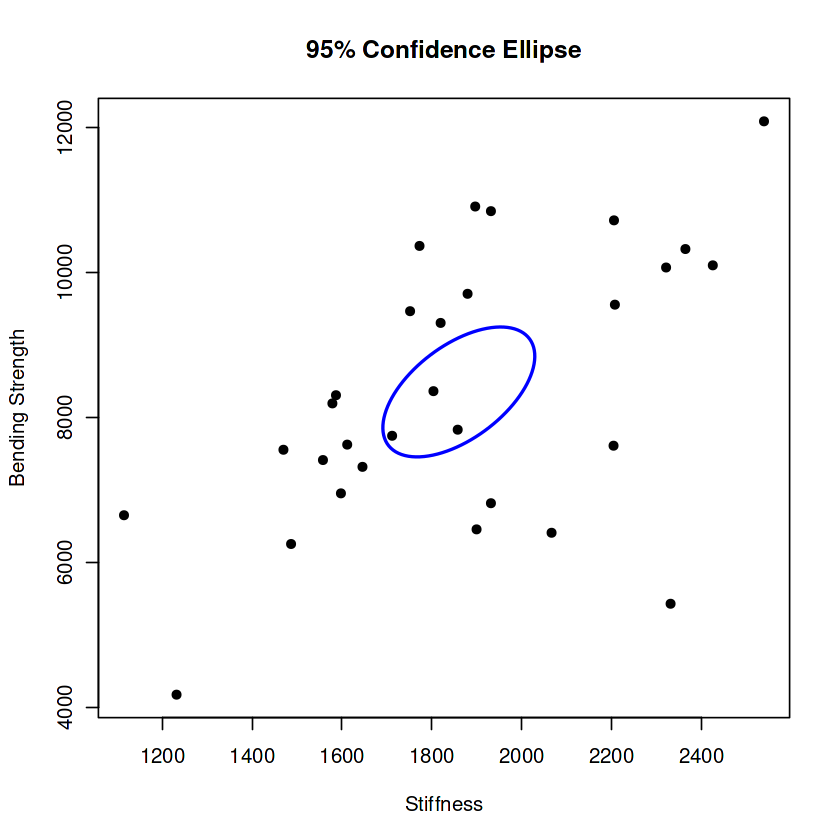

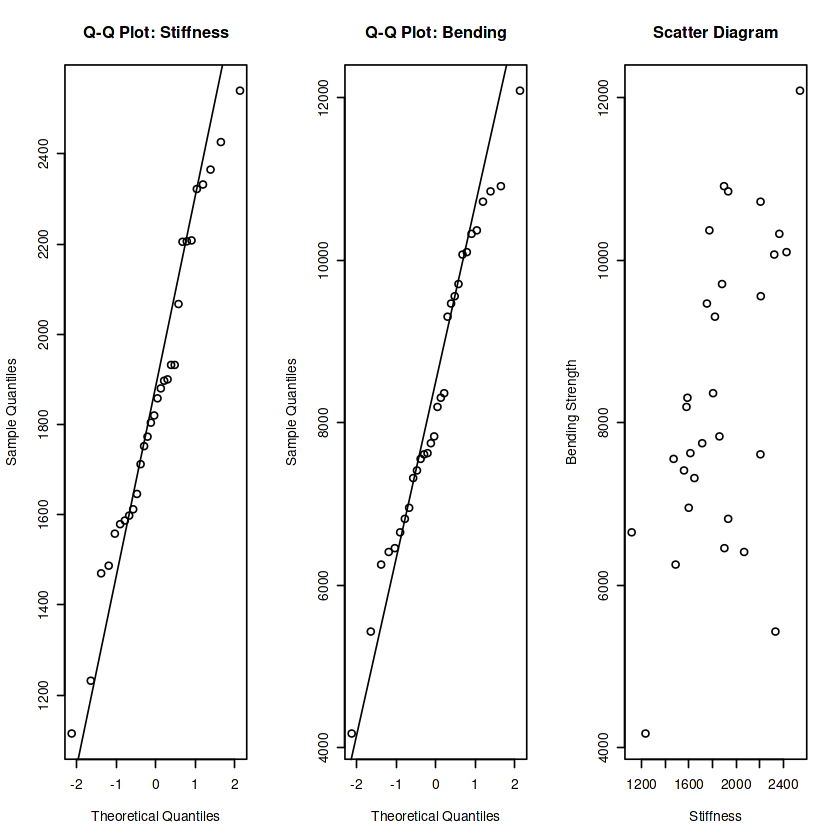

In [104]:
stiffness <- c(1232, 1115, 2205, 1897, 1932, 1612, 1598, 1804, 1752, 2067, 
               2365, 1646, 1579, 1880, 1773, 1712, 1932, 1820, 1900, 2426, 
               1558, 1470, 1858, 1587, 2208, 1487, 2206, 2332, 2540, 2322)
bending <- c(4175, 6652, 7612, 10914, 10850, 7627, 6954, 8365, 9469, 6410, 
             10327, 7320, 8196, 9709, 10370, 7749, 6818, 9307, 6457, 10102, 
             7414, 7556, 7833, 8309, 9559, 6255, 10723, 5430, 12090, 10072)
lumber <- data.frame(Stiffness = stiffness, Bending = bending)

n <- nrow(lumber)
p <- 2
alpha <- 0.05
x_bar <- colMeans(lumber)
S <- cov(lumber)

# a
alpha <- 0.05
F_crit <- qf(1 - alpha, df1 = p, df2 = n - p)
radius <- sqrt( ((n - 1) * p / (n - p)) * F_crit / n )

plot(lumber_data, xlab = "Stiffness", ylab = "Bending Strength", 
     main = "95% Confidence Ellipse", pch = 16)
lines(ellipse::ellipse(S, centre = x_bar, t = radius), col = "blue", lwd =2)

# b
mu_0 <- c(2000, 10000)
T2 <- n * t(x_bar - mu_0) %*% solve(S) %*% (x_bar - mu_0)
T2_crit <- ((n - 1) * p / (n - p)) * qf(1 - alpha, p, n - p)

cat("Test for Typical Values [2000, 10000]'\n")
cat("T^2 statistic:", as.numeric(T2), "\n")
cat("Critical Value:", T2_crit, "\n")
if(as.numeric(T2) > T2_crit) {
  cat("Result: Data is not consistent with these values (Reject H0)\n")
} else {
  cat("Result: Data is consistent with these values (Do not Reject H0)\n")
}

# c
par(mfrow = c(1, 3))
qqnorm(lumber$Stiffness, main = "Q-Q Plot: Stiffness"); qqline(lumber$Stiffness)
qqnorm(lumber$Bending, main = "Q-Q Plot: Bending"); qqline(lumber$Bending)
plot(lumber$Stiffness, lumber$Bending, main = "Scatter Diagram", 
     xlab = "Stiffness", ylab = "Bending Strength")
par(mfrow = c(1, 1))

a. The 95% confidence ellipse was successfully created and plotted. It is centered around the sample mean and tilted upward, showing a positive relationship between lumber stiffness and bending strength.

b. The sample data does not match the proposed typical values of $\mu_{10} = 2000$ for stiffness and $\mu_{20} = 10,000$ for bending strength. The calculated Hotelling's $T^2$ value is 23.64778, which is higher than the critical value of 6.91937. Therefore, the null hypothesis is rejected. The point [2000, 10000]' would also be outside the 95% confidence ellipse.

c. The data appears to be reasonably consistent with a bivariate normal distribution. The Q-Q plots show that the values are close to the expected straight lines, while the scatter plot shows a roughly elliptical pattern with a positive relationship. There are also no major outliers, which supports the assumption of bivariate normality.